# Olist E-Commerce: Delivery, Reviews, and Location Analysis

**Dataset:** I am using the [Brazilian E-Commerce Public Dataset by 
Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). 
It contains information about roughly 100,000 orders made in Brazil 
between 2016 and 2018.

**What I wanted to learn:** Whether orders that arrived after their 
estimated delivery date received different customer review scores, 
whether this varies by location (customer state vs. seller state), 
and whether product category plays a role.

**What I did in this notebook:** I loaded all nine CSV files, 
inspected and cleaned the core `orders` table (handling missing 
timestamps and converting date columns), engineered delivery-time and 
lateness features, and merged in reviews, customer location, product 
categories, and seller location to answer the questions above. I 
explain each step below in my own words and point out data quality 
issues I found along the way.

**Tools used:** Python (pandas, NumPy) for cleaning and analysis, 
Matplotlib and Seaborn for visualization. SQL analysis (replicating 
key findings with joins and aggregate queries) is planned as a 
follow-up.

## 1. Load the source data

The Olist data is split across nine CSV files. I read each file into its own pandas DataFrame so I can work with the different parts of the dataset separately. I also put the DataFrames into a dictionary called `tables`. This lets me print the size of each table in one loop.

At this point, I am only loading the files and checking their dimensions. I have not removed rows or changed the data yet.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

tables = {
    'orders': orders, 
    'order_items': order_items, 
    'customers': customers,
    'products': products, 
    'sellers': sellers, 
    'payments': payments,
    'reviews': reviews, 
    'geolocation': geolocation,
    'category_translation': category_translation
}
for name, df in tables.items():
    print(f"{name}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
payments: (103886, 5)
reviews: (99224, 7)
geolocation: (1000163, 5)
category_translation: (71, 2)


### What the table sizes tell me

The files loaded successfully. The `orders` table has 99,441 rows. Some other tables have more rows: `order_items` has 112,650 and `payments` has 103,886. That makes sense because one order can contain several items or have more than one payment record.

The review table has 99,224 rows, which is fewer than the number of orders, so not every order has a review record. The geolocation table is much larger, with over one million rows, because it stores many location observations for postal-code areas.

I should not assume that every table has one row for every order. Before I join tables later, I need to check what one row represents in each table. I find repeated order IDs in the review table near the end of this notebook.

## 2. Start by understanding the `orders` table

I am starting with `orders` because it has one row for each order and contains the timestamps I need for delivery analysis. It also has the order status and customer ID, which will help me connect orders to other information later.

Before calculating anything, I check the table's columns, data types and missing values. This helps me understand what the data contains and what preparation is needed.

I use `orders.info()` to see how many rows and columns the table has, how many values are present in each column, and what type pandas assigned to each column. In particular, I want to check whether the date columns are ready for date calculations.

In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


I count missing values in every column. This gives me a quick way to see which fields are complete and which fields need more attention.

In [6]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### What I found in the order table

The five timestamp columns were loaded as strings. A string is text, so I cannot safely subtract these values to measure delivery time until I convert them to dates.

Some timestamps are missing. There are 160 missing approval dates, 1,783 missing dates for when the order was handed to the carrier, and 2,965 missing customer-delivery dates. These fields describe steps in an order's journey. If an order was canceled or had not reached a particular step, a later date may not exist.

For that reason, I keep these rows and leave the missing dates empty. I do not make up dates or remove the whole order. Later, calculations that need a missing date will naturally have no result for that order.

I display `orders` to look at example records and check that the columns contain the kind of values I expect. Since the table has nearly 100,000 rows, pandas shows only part of it rather than printing every row.

In [7]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


I convert the five timestamp columns from text to pandas datetime values with `pd.to_datetime`. This allows me to compare and subtract dates. I then check the table information again to make sure pandas now recognizes these columns as datetimes. Missing dates stay missing after the conversion.

In [8]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [9]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


I count the number of orders in each status. This helps me understand how many orders were completed and how many were still in progress or did not complete. I will compare these counts with the missing timestamps to see whether the gaps are reasonable.

In [10]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Order status and delivery-date coverage

Most orders are marked `delivered` (96,478). The other statuses are `shipped` (1,107), `canceled` (625), `unavailable` (609), `invoiced` (314), `processing` (301), `created` (5) and `approved` (2).

There are 96,476 orders with a customer-delivery date. That is two fewer than the number marked `delivered`, so I check which rows explain the difference instead of assuming the counts match.

I filter the table to find orders that are marked as delivered but have no customer-delivery date. This lets me inspect the specific records behind the difference in the two counts.

In [11]:
orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isna())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


### A data issue I found: delivered orders without delivery dates

I found eight rows marked `delivered` that do not have a customer-delivery timestamp. This is a mismatch in the source data. I keep these order records, because the rest of their information may still be useful, but I cannot calculate their delivery duration or delay without the missing date.

One of these eight rows is also missing its approval date. I leave the missing values as they are instead of guessing what the dates should have been. Any calculation that needs the missing delivery date will leave that order out automatically.

## 3. Prepare the dates and calculate delivery measures

Now I use the timestamps to describe how long orders took and whether they arrived after Olist's estimate. I calculate these measures:

- `delivery_time_days` is the number of whole days from the purchase date to the date the customer received the order.
- `delivery_delay_days` compares the actual delivery date with the estimated delivery date. A positive number means the order was late; a negative number means it arrived early.
- `is_late` is `True` when the delay is greater than zero. An order delivered on its estimated date is counted as not late.

If an order has no actual delivery date, these measures cannot be calculated and remain empty for that row.

In [12]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [13]:
# Delivery time: purchase to actual delivery (in days)
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# Was delivery late vs. Olist's own estimate?
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late'] = orders['delivery_delay_days'] > 0

# Quick sanity check
orders[['delivery_time_days', 'delivery_delay_days']].describe()

,delivery_time_days,delivery_delay_days
count,96476.000000,96476.000000
mean,12.094086,-11.876881
std,9.551746,10.183854
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


I calculate the delivery measures and then use `describe()` to review their count, average, middle value, spread, smallest value and largest value. The `.dt.days` operation expresses the difference in whole days, so it does not preserve partial days or hours. Rows missing a date needed for a calculation are not included in that calculation's statistics.

In [14]:
orders[orders['delivery_time_days'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,is_late


I calculate what percentage of orders are marked late and not late. I use normalized value counts so the results are percentages rather than raw counts. This calculation only includes orders where I was able to calculate whether delivery was late.

In [15]:
# What % of orders were actually late vs early/on-time?
orders['is_late'].value_counts(normalize=True) * 100

is_late
False    93.428264
True      6.571736
Name: proportion, dtype: float64

### How often orders arrived after the estimate

In the current data, about 6.6% of orders with a recorded delivery date arrived after the estimated date. About 93.4% arrived on or before the estimate. This tells me how actual deliveries compare with Olist's estimates. By itself, it does not tell me why the estimates were earlier or later than actual delivery.

I check how many records were more than 100 days late. The code selects those records and calls `.count()` for each column, so the output shows a count of 39 for each field. This means there are 39 records in this group; it does not show their order IDs or prove whether the values are errors.

In [16]:
orders[orders['delivery_delay_days'] > 100][['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days']].count()

order_id                         39
order_purchase_timestamp         39
order_delivered_customer_date    39
order_estimated_delivery_date    39
delivery_delay_days              39
dtype: int64

### What I learned from the delivery checks

I did not find any orders with a negative purchase-to-delivery duration in my check. Among the rows with the dates needed for the calculation, the average delivery time is about 12.1 days and the median is 10 days.

The average delivery delay is about ?11.9 days. Since negative values mean early delivery, this says that deliveries were, on average, nearly 12 days earlier than the estimated date in this dataset. This describes the data; it does not explain how Olist chose its estimates.

I also found 39 records that were more than 100 days later than estimated. I have not removed them. They could affect averages, so I should keep them in mind when I present results. I would need to inspect the individual records before deciding whether any are data errors.

## 4. Begin comparing delivery timing with review scores

I now connect order information to customer review scores. My question is whether the scores differ between orders that arrived late and orders that arrived on time or early.

This is an initial comparison. A difference in scores can show an association, but it cannot by itself prove that late delivery caused the difference. I also need to check how many review records belong to each order before relying on the results.

In [17]:
# Merge orders with reviews
orders_reviews = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Check the merge worked as expected
print(orders_reviews.shape)
orders_reviews['review_score'].isna().sum()

(99992, 12)


np.int64(768)

In [18]:
orders_reviews.groupby('is_late')['review_score'].agg(['mean', 'median', 'count'])

,mean,median,count
is_late,,,
False,4.211789,5.0,92814
True,2.271139,1.0,6410


In [19]:
reviews['order_id'].duplicated().sum()

np.int64(551)

I display the review table to see what information it contains. Each row includes a review ID, an order ID, a score, optional written comments and dates related to the review. Some comment fields are empty, even when a score is present.

Because an order can appear more than once here, I need a clear rule for combining or selecting reviews if I want to make a comparison where each order has equal weight.

In [20]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [21]:
dup_ids = reviews[reviews['order_id'].duplicated(keep=False)]['order_id']
reviews[reviews['order_id'].isin(dup_ids)].sort_values('order_id').head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


### Prepare one review per order

To address the repeated order IDs I found, I sort the reviews by `review_creation_date` and keep the last review for each order. This gives me one review score per order for the next merge. It is a practical choice for this analysis, but it means I am using the most recently created review when an order has more than one. I should keep that rule in mind when interpreting the result.

In [22]:
reviews_dedup = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')
print(reviews.shape, '->', reviews_dedup.shape)

(99224, 7) -> (98673, 7)


I now merge the deduplicated review table with the orders. Since there is at most one selected review per order, this join should no longer add extra order rows. I print the resulting shape to check the merge.

In [23]:
orders_reviews = orders.merge(reviews_dedup[['order_id', 'review_score']], on='order_id', how='left')
print(orders_reviews.shape)

(99441, 12)


I repeat the review-score summary using the table with one review per order. This makes the comparison easier to interpret because each order can contribute no more than one review score. I compare the new output with the earlier summary, while remembering that orders without reviews have no score and are not included in the score averages.

In [24]:
orders_reviews.groupby('is_late')['review_score'].agg(['mean', 'median', 'count'])

,mean,median,count
is_late,,,
False,4.211797,5.0,92291
True,2.270918,1.0,6382


### Key Finding: Late Delivery Strongly Predicts Poor Reviews

| | Mean Review Score | Median | Count |
|---|---|---|---|
| On-time/Early | 4.21 | 5.0 | 92,291 |
| Late | 2.27 | 1.0 | 6,382 |

Late orders score **nearly 2 points lower on average**, and the median 
score drops from a top rating (5) to the worst possible rating (1). 
This is a strong, clear, quantifiable business finding: late delivery 
is a major driver of customer dissatisfaction on the platform.

## 5. Visualizing the Delivery–Review Relationship

A bar chart makes the late-delivery penalty immediately visible.

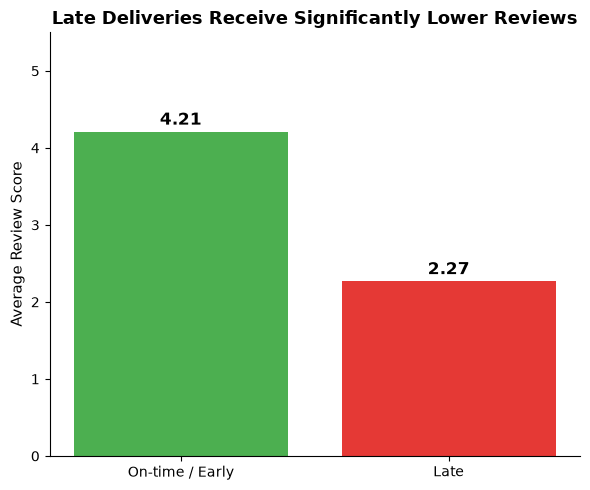

In [25]:
import matplotlib.pyplot as plt

avg_scores = orders_reviews.groupby('is_late')['review_score'].mean()

labels = ['On-time / Early', 'Late']
colors = ['#4CAF50', '#E53935']  # green for on-time, red for late

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, avg_scores.values, color=colors)

# Add the actual value on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Average Review Score', fontsize=11)
ax.set_title('Late Deliveries Receive Significantly Lower Reviews', fontsize=13, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../notebooks/delivery_vs_reviews.png', dpi=150)  # saves for README use
plt.show()

On-time/early orders average **4.21 out of 5**, while late orders 
average only **2.27 out of 5** — a drop of nearly 2 full points. Since 
mean scores can be skewed by a handful of extreme ratings, this result 
is checked against the median too: on-time orders have a median score 
of **5.0**, while late orders have a median of just **1.0**. Both 
measures point the same direction, suggesting this isn't a 
small-sample fluke but a consistent pattern across tens of thousands 
of orders.

### Review Score Distribution: On-time vs. Late

To confirm this isn't just a few extreme reviews skewing the average, 
here's the full distribution of review scores (1–5) for each group.

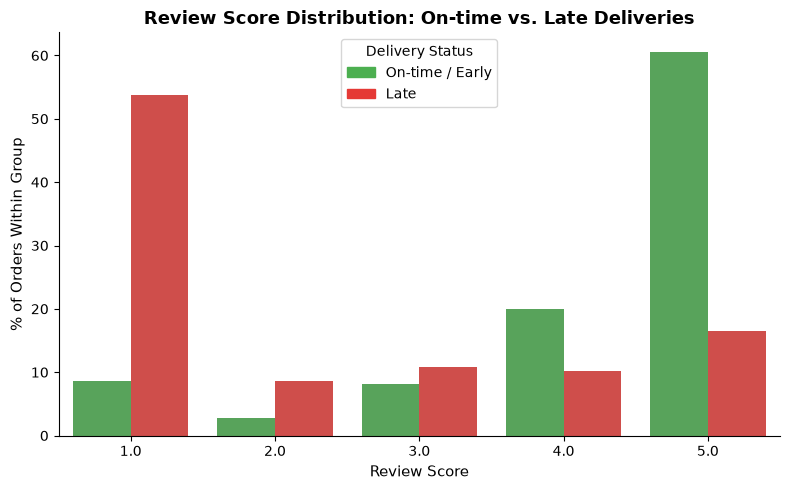

In [27]:
# Compute percentages within each group manually, so group sizes don't distort the comparison
import matplotlib.patches as mpatches
dist = (
    orders_reviews.dropna(subset=['review_score'])
    .groupby('is_late')['review_score']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=dist,
    x='review_score',
    y='percent',
    hue='is_late',
    palette={False: '#4CAF50', True: '#E53935'},
    ax=ax
)

ax.set_xlabel('Review Score', fontsize=11)
ax.set_ylabel('% of Orders Within Group', fontsize=11)
ax.set_title('Review Score Distribution: On-time vs. Late Deliveries', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Manually build legend patches with the correct colors
green_patch = mpatches.Patch(color='#4CAF50', label='On-time / Early')
red_patch = mpatches.Patch(color='#E53935', label='Late')
ax.legend(handles=[green_patch, red_patch], title='Delivery Status')

plt.tight_layout()
plt.savefig('../notebooks/review_distribution.png', dpi=150)
plt.show()

### Interpreting the Distribution

This chart normalizes within each group separately, so the green and 
red bars are directly comparable regardless of how many orders fall 
into each group.

**On-time/early deliveries (green):** heavily skewed toward 5-star 
reviews — about 61% of on-time orders receive the top rating, and 
only ~9% receive a 1-star.

**Late deliveries (red):** the pattern flips almost completely. 
Over 53% of late orders receive a 1-star review, while only ~16% 
still manage a 5-star rating.

This confirms the earlier mean/median finding wasn't driven by a 
handful of extreme reviews — it reflects a genuine shift in the 
*entire distribution* of customer sentiment. A late delivery doesn't 
just nudge the rating down slightly; it roughly **flips the most 
likely outcome from 5-stars to 1-star**.

Interestingly, late orders aren't universally rated poorly — about 
16% of late orders still receive 5 stars, suggesting delivery delay 
alone doesn't guarantee dissatisfaction, but it dramatically shifts 
the odds.

## 6. Where Is Delivery Performance Worst? A State-Level Breakdown

Now that we know late delivery strongly hurts reviews, the natural 
follow-up question is: **where in Brazil does this happen most?** 
This merges in customer location data to find which states have the 
highest late-delivery rates and lowest average review scores.

In [28]:
# customers table has customer_state; merge it into orders_reviews
orders_full = orders_reviews.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

orders_full['customer_state'].isna().sum()  # sanity check — should be 0

np.int64(0)

In [29]:
state_summary = orders_full.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_time_days', 'mean')
).round(2)

# Only look at states with a meaningful number of orders
state_summary = state_summary[state_summary['total_orders'] >= 100]
state_summary = state_summary.sort_values('late_rate_pct', ascending=False)

state_summary.head(15)

,total_orders,late_rate_pct,avg_review_score,avg_delivery_days
customer_state,,,,
AL,413,20.58,3.76,24.04
MA,747,16.73,3.76,21.12
SE,350,14.57,3.81,21.03
PI,495,13.33,3.92,18.99
CE,1336,13.17,3.86,20.82
BA,3380,11.72,3.86,18.87
RJ,12852,11.63,3.88,14.85
PA,975,10.87,3.85,23.32
ES,2033,10.53,4.04,15.33


Delivery delays are not evenly distributed across Brazil — they're concentrated in the Northeast region (AL, MA, SE, PI, CE, BA), where late-delivery rates are 2–3x the national average and directly correlate with lower review scores. Olist's logistics team should prioritize carrier partnerships or fulfillment infrastructure investment in this region specifically, rather than applying a uniform national fix.

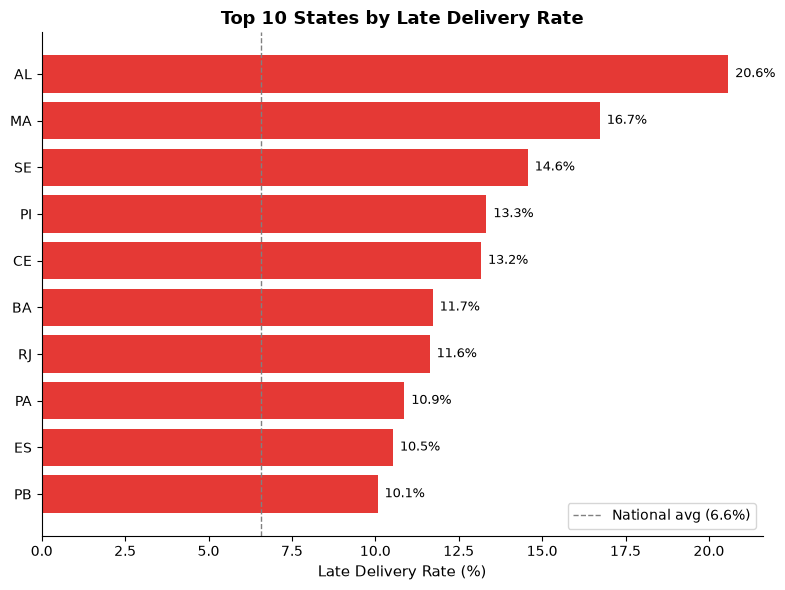

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
top_states = state_summary.head(10).sort_values('late_rate_pct')  # ascending for horizontal bar order

bars = ax.barh(top_states.index, top_states['late_rate_pct'], color='#E53935')
ax.axvline(x=6.57, color='gray', linestyle='--', linewidth=1, label='National avg (6.6%)')

ax.set_xlabel('Late Delivery Rate (%)', fontsize=11)
ax.set_title('Top 10 States by Late Delivery Rate', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/late_rate_by_state.png', dpi=150)
plt.show()

Every state in the top 10 has a late-delivery rate **above the 
national average of 6.6%** — in some cases by a wide margin. 
**Alagoas (AL)** is the clear outlier, with a late-delivery rate of 
**20.6%**, more than 3x the national average, followed by **Maranhão 
(MA)** at 16.7% and **Sergipe (SE)** at 14.6%.

Notably, 7 of these 10 states (AL, MA, SE, PI, CE, BA, PB) are in 
Brazil's **Northeast region**. This geographic clustering suggests 
the issue isn't random variation but a **regional logistics 
infrastructure problem** — likely tied to carrier coverage, 
warehouse proximity, or transport routes serving the Northeast.

**Recommendation:** Rather than applying a uniform national fix, 
Olist's logistics team should prioritize carrier partnerships and 
fulfillment infrastructure specifically in the Northeast region, 
starting with Alagoas and Maranhão, where delivery delays — and the 
resulting customer dissatisfaction — are most severe.

## 7. Product Category & Seller Analysis

So far the analysis has used `orders`, `reviews`, and `customers`. 
This section brings in the remaining core tables — `order_items`, 
`products`, `sellers`, and `category_translation` — to answer a new 
question: **which product categories and sellers are most associated 
with late delivery and poor reviews?**

Note: an order can contain multiple items from different sellers, so 
this analysis works at the **order-item level** rather than the 
order level used earlier.

In [31]:
# Start from order_items, since this is the item-level granularity we need
items_full = order_items.merge(products, on='product_id', how='left')
items_full = items_full.merge(category_translation, on='product_category_name', how='left')
items_full = items_full.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

# Bring in order-level info we already engineered: is_late, review_score
items_full = items_full.merge(
    orders_full[['order_id', 'is_late', 'review_score', 'delivery_time_days']],
    on='order_id',
    how='left'
)

print(items_full.shape)
items_full[['order_id', 'product_category_name_english', 'seller_state', 'is_late', 'review_score']].head()

(112650, 20)


,order_id,product_category_name_english,seller_state,is_late,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,SP,False,5.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,SP,False,4.0
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,MG,False,5.0
3,00024acbcdf0a6daa1e931b038114c75,perfumery,SP,False,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,PR,False,5.0


In [32]:
items_full['product_category_name_english'].isna().sum()

np.int64(1627)

In [33]:
# How many are missing because product itself had no category at all?
items_full['product_category_name'].isna().sum()

np.int64(1603)

1,627 order items (1.4% of all items) have no product category. Of these, 1,603 are due to the product itself having no category assigned in the source data, and 24 are due to a missing translation entry for an otherwise-valid category name.

In [34]:
items_full['product_category_name_english'] = items_full['product_category_name_english'].fillna('Unknown')

In [35]:
category_summary = items_full.groupby('product_category_name_english').agg(
    total_items=('order_id', 'count'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100),
    avg_review_score=('review_score', 'mean')
).round(2)

# Keep only categories with meaningful volume
category_summary = category_summary[category_summary['total_items'] >= 100]
category_summary = category_summary.sort_values('late_rate_pct', ascending=False)

category_summary.head(15)

,total_items,late_rate_pct,avg_review_score
product_category_name_english,,,
audio,364,11.54,3.83
christmas_supplies,153,9.80,4.02
home_confort,434,9.22,3.83
fashion_underwear_beach,131,9.16,3.98
books_technical,267,7.87,4.36
office_furniture,1691,7.87,3.49
electronics,2767,7.48,4.04
baby,3065,7.47,4.01
health_beauty,9670,7.41,4.14


### Category-Level Late Delivery & Review Patterns

| Category | Late Rate | Avg Review |
|---|---|---|
| audio | 11.54% | 3.83 |
| christmas_supplies | 9.80% | 4.02 |
| home_confort | 9.22% | 3.83 |
| fashion_underwear_beach | 9.16% | 3.98 |
| office_furniture | 7.87% | 3.49 |

`audio` has the highest late-delivery rate (11.5%) among categories 
with meaningful volume — nearly double the platform average. Furniture 
categories (`office_furniture`, `furniture_living_room`) also show 
elevated late rates, loosely supporting the idea that bulkier items 
may be harder to ship on time.

Unlike the state-level finding, the relationship between late delivery 
and review score is **weaker at the category level** — some categories 
with above-average late rates (e.g. `books_technical`) still maintain 
relatively strong review scores. This suggests delivery geography is a 
stronger driver of customer dissatisfaction than product category alone.

### Does Seller Location Predict Late Delivery?

The state-level analysis earlier looked at the **customer's** state. 
This checks the **seller's** state instead — are certain sellers' 
regions worse at shipping on time, regardless of where the order is going?

In [37]:
seller_state_summary = items_full.groupby('seller_state').agg(
    total_items=('order_id', 'count'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100),
    avg_review_score=('review_score', 'mean')
).round(2)

seller_state_summary = seller_state_summary[seller_state_summary['total_items'] >= 100]
seller_state_summary = seller_state_summary.sort_values('late_rate_pct', ascending=False)

seller_state_summary.head(15)

,total_items,late_rate_pct,avg_review_score
seller_state,,,
MA,405,19.26,4.00
SP,80342,6.95,4.00
RJ,4818,6.72,4.10
DF,899,5.90,4.03
ES,372,5.65,4.01
PR,8671,5.19,4.07
SC,4075,4.76,4.10
MG,8827,4.67,4.11
BA,643,4.35,4.09


### Seller State vs. Customer State: A Different Story

Interestingly, this breakdown tells a different story than the 
customer-state analysis. Most sellers (80,342 of ~112K items) are 
based in **São Paulo (SP)**, Brazil's commercial hub, with a late 
rate close to the platform average (6.95%).

**Maranhão (MA)** stands out as the one seller state with a notably 
high late rate (19.3%), though from a small base (405 items).

Critically, states that looked problematic in the *customer*-state 
analysis (e.g. **Bahia**) are NOT problematic here as *seller* states 
— BA sellers actually have one of the lowest late rates (4.35%). 

This suggests the earlier Northeast finding is less about sellers in 
that region being unreliable, and more about the **logistics challenge 
of shipping to the Northeast** from sellers concentrated elsewhere 
(primarily SP). This reframes the recommendation: rather than 
"improve Northeastern seller operations," the fix is more likely 
**improving shipping routes/carrier coverage into the Northeast**, 
since most products ship *from* elsewhere *to* that region.

## 8. Summary & Recommendations

**Key Findings:**

1. **Late delivery severely damages customer satisfaction.** Orders 
   delivered late average a 2.27/5 review score versus 4.21/5 for 
   on-time orders — a drop of nearly 2 full points. This isn't driven 
   by outliers: the entire rating distribution shifts, with 53% of 
   late orders receiving 1-star reviews versus just 9% of on-time 
   orders.

2. **Only 6.6% of orders are actually late** — Olist's delivery 
   estimates are conservative (orders arrive ~12 days earlier than 
   estimated on average), but when delays do happen, the satisfaction 
   cost is severe.

3. **Delivery delays are geographically concentrated on the receiving 
   end.** Customers in Brazil's Northeast region — particularly 
   Alagoas (20.6% late rate) and Maranhão (16.7%) — experience late 
   deliveries 2–3x the national average.

4. **The bottleneck is shipping *to* the Northeast, not sellers based 
   *in* it.** When the same regions are analyzed by seller location 
   instead of customer location, the pattern disappears — e.g. Bahia 
   sellers actually have one of the lowest late rates (4.35%), despite 
   Bahia customers facing elevated delays. Since most sellers are 
   concentrated in São Paulo, this points to a logistics/carrier 
   coverage gap on routes into the Northeast, rather than a regional 
   seller performance issue.

5. **Product category has a weaker, more mixed effect.** `audio` 
   (11.5% late) and furniture categories show elevated late rates, 
   but the link to review scores is less consistent than the 
   geographic pattern — some high-late-rate categories (e.g. 
   `books_technical`) still retain strong review scores.

**Recommendation:** Olist should prioritize improving carrier/shipping 
routes into the Northeast region — rather than auditing sellers based 
there — since the data shows the delay originates in transit to that 
region, not in regional seller operations. Given the strong link 
between delays and 1-star reviews, even a modest improvement in 
delivery reliability for this corridor could meaningfully lift overall 
platform review scores.

**Data quality notes:**
- Converted all order timestamp columns from string to datetime.
- Missing delivery timestamps follow a clear order-status funnel 
  (canceled/processing/shipped orders naturally lack delivery dates) 
  — not random data loss.
- Flagged 8 orders marked `delivered` with a missing delivery date.
- Deduplicated 551 orders with multiple review entries, keeping the 
  most recent review per order.
- 1,627 order items (1.4%) had no product category; labeled as 
  "Unknown" rather than dropped.

**Tools used:** Python (pandas, NumPy) for cleaning and feature 
engineering, Matplotlib/Seaborn for visualization. SQL analysis 
(replicating key findings with joins and aggregate queries) covered 
in a separate section/notebook.